In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [12]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

In [10]:
print(nav.shape)
print(performance.shape)
print(transactions.shape)

(46000, 3)
(40, 19)
(32778, 13)


In [11]:
print(nav.columns)
print(performance.columns)
print(transactions.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [13]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [15]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [16]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


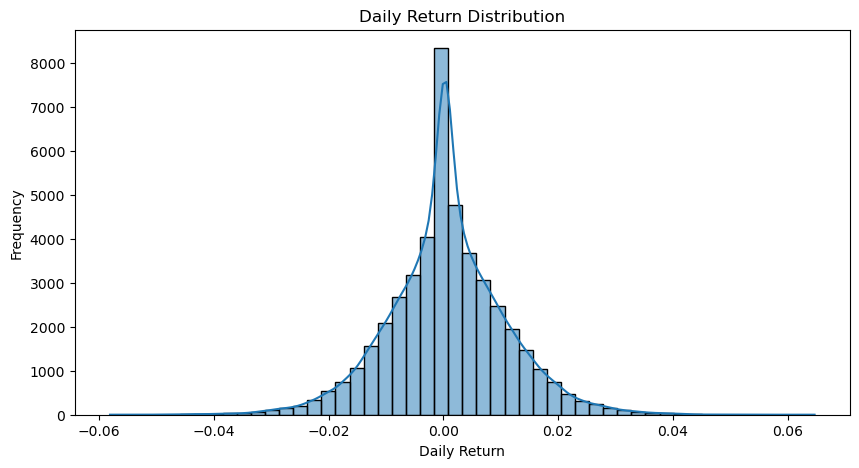

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [18]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [19]:
nav.to_csv(
    "../data/processed/nav_daily_returns.csv",
    index=False
)

print("Daily Returns Saved Successfully")

Daily Returns Saved Successfully


## Daily Returns Analysis

Daily returns were calculated for all 40 mutual fund schemes using percentage change in NAV values. The return distribution is approximately centered around zero, indicating normal market fluctuations with occasional extreme movements.

In [20]:
performance[[
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]].head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [21]:
cagr_table = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]]

cagr_table = cagr_table.sort_values(
    "return_5yr_pct",
    ascending=False
)

cagr_table.head(10)

,amfi_code,scheme_name,fund_house,return_1yr_pct,return_3yr_pct,return_5yr_pct
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,21.30,20.15,21.88
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,20.59,23.14,21.82
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,24.56,23.39,20.67
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.20,20.08,20.61
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,14.12,17.16,19.00
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,14.88,15.18,18.94
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,17.12,18.23,17.75
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,15.43,16.58,17.69


In [22]:
cagr_table.to_csv(
    "../reports/cagr_comparison_table.csv",
    index=False
)

print("CAGR table saved")

CAGR table saved


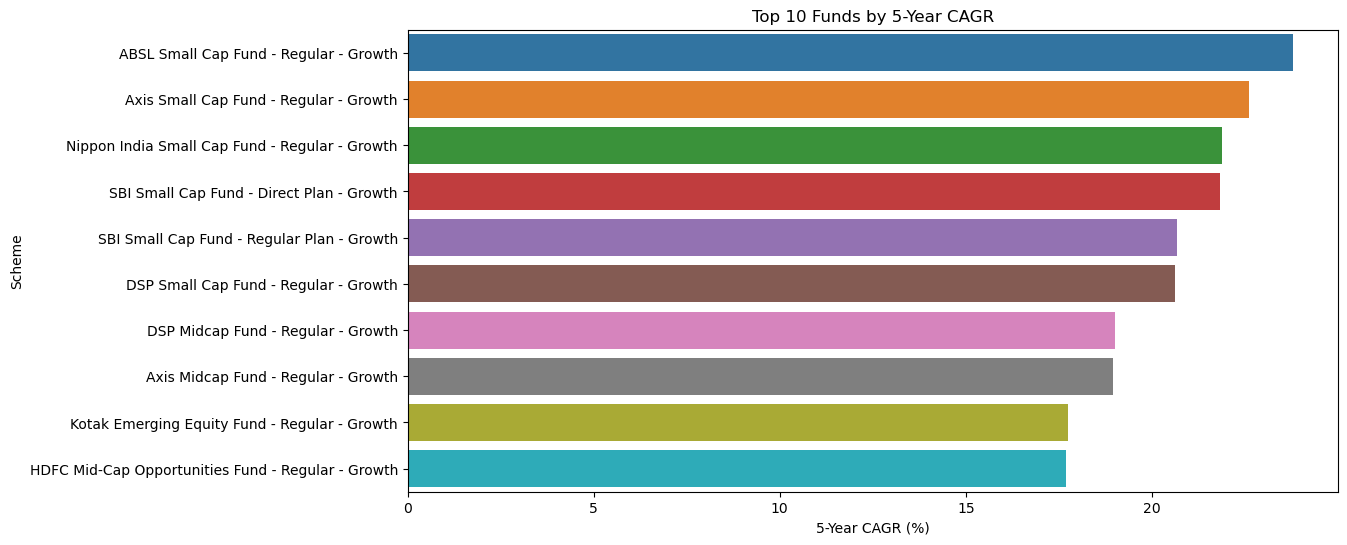

In [23]:
top10 = cagr_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year CAGR")
plt.xlabel("5-Year CAGR (%)")
plt.ylabel("Scheme")

plt.show()

## CAGR Comparison Analysis

The CAGR comparison indicates significant variation in long-term fund performance. The top-performing schemes delivered the highest 5-year annualized returns, demonstrating stronger wealth creation potential over extended investment horizons.

In [24]:
cagr_table.head()

,amfi_code,scheme_name,fund_house,return_1yr_pct,return_3yr_pct,return_5yr_pct
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,21.30,20.15,21.88
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,20.59,23.14,21.82
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,24.56,23.39,20.67


In [25]:
sharpe_rank = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "sharpe_ratio"
]]

sharpe_rank = sharpe_rank.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_rank.head(10)

,amfi_code,scheme_name,fund_house,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,1.52
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,1.33
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.06
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.00


In [26]:
sharpe_rank.to_csv(
    "../reports/sharpe_ranking.csv",
    index=False
)

print("Sharpe ranking saved")

Sharpe ranking saved


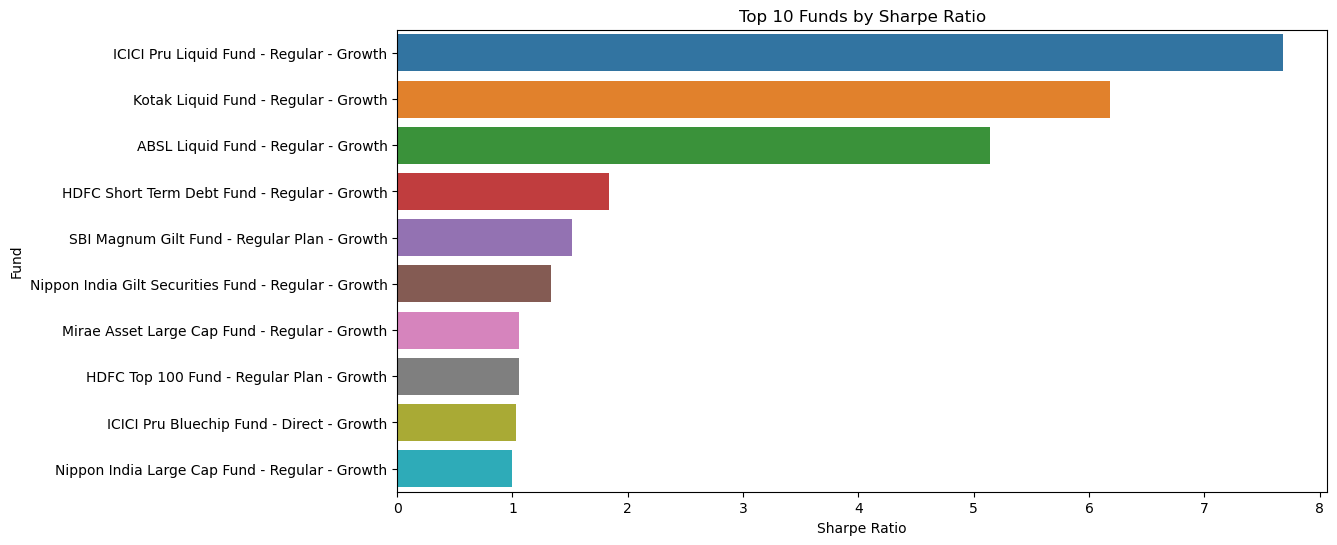

In [27]:
top10_sharpe = sharpe_rank.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund")

plt.show()

## Sharpe Ratio Analysis

Sharpe Ratio measures risk-adjusted return. Higher Sharpe values indicate better returns generated per unit of total risk. The top-ranked funds demonstrated superior risk-adjusted performance relative to their peers.

In [28]:
plt.savefig("../reports/sharpe_ranking.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [29]:
sharpe_rank.head()

,amfi_code,scheme_name,fund_house,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,1.52


In [30]:
sortino_rank = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "sortino_ratio"
]]

sortino_rank = sortino_rank.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_rank.head(10)

,amfi_code,scheme_name,fund_house,sortino_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,10.37
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,9.70
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,8.76
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,2.79
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,2.38
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,2.11
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.70
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.68
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,1.67
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.66


In [31]:
sortino_rank.to_csv(
    "../reports/sortino_ranking.csv",
    index=False
)

print("Sortino ranking saved")

Sortino ranking saved


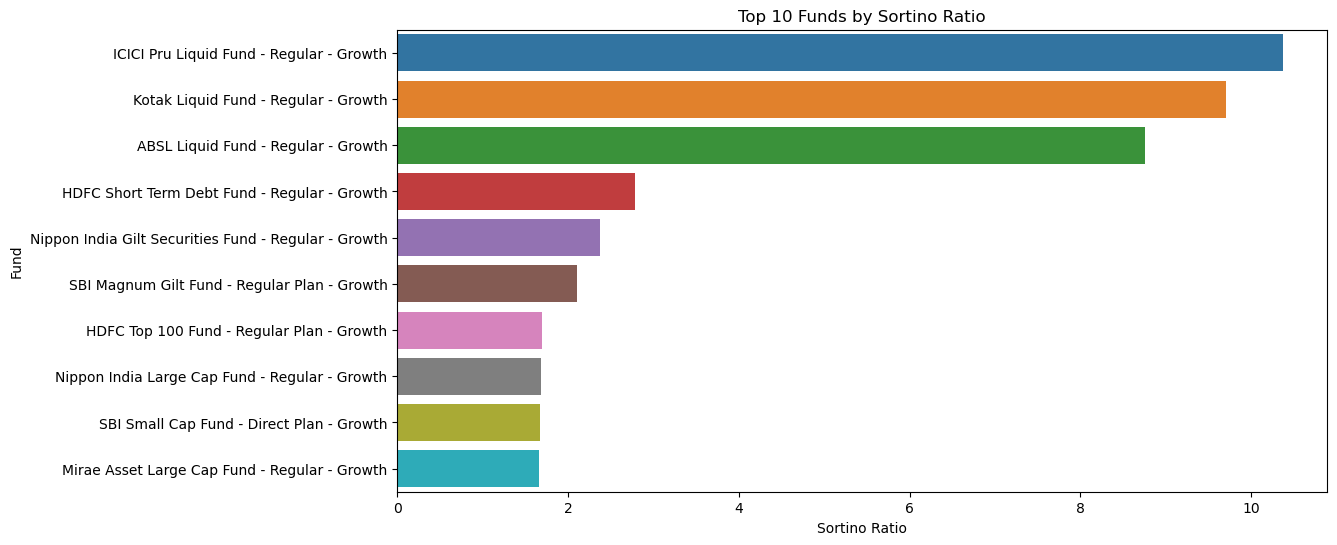

In [32]:
top10_sortino = sortino_rank.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Fund")

plt.show()

In [33]:
plt.savefig(
    "../reports/sortino_ranking.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Sortino Ratio Analysis

The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility. Higher values indicate that a fund generates better returns while minimizing negative return fluctuations.

In [34]:
sortino_rank.head()

,amfi_code,scheme_name,fund_house,sortino_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,10.37
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,9.70
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,8.76
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,2.79
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,2.38


In [35]:
alpha_beta = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "alpha",
    "beta"
]]

alpha_beta.head()

,amfi_code,scheme_name,fund_house,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,1.60,0.22


In [36]:
alpha_rank = alpha_beta.sort_values(
    "alpha",
    ascending=False
)

alpha_rank.head(10)

,amfi_code,scheme_name,fund_house,alpha,beta
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.98,0.44
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,1.91,1.00
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,1.85,0.26
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.85,0.95
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.84,0.97
37,149322,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,1.82,0.91
18,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,1.80,1.04
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,1.79,1.00
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,1.78,0.87
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,1.70,0.99


In [37]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta file saved")

Alpha Beta file saved


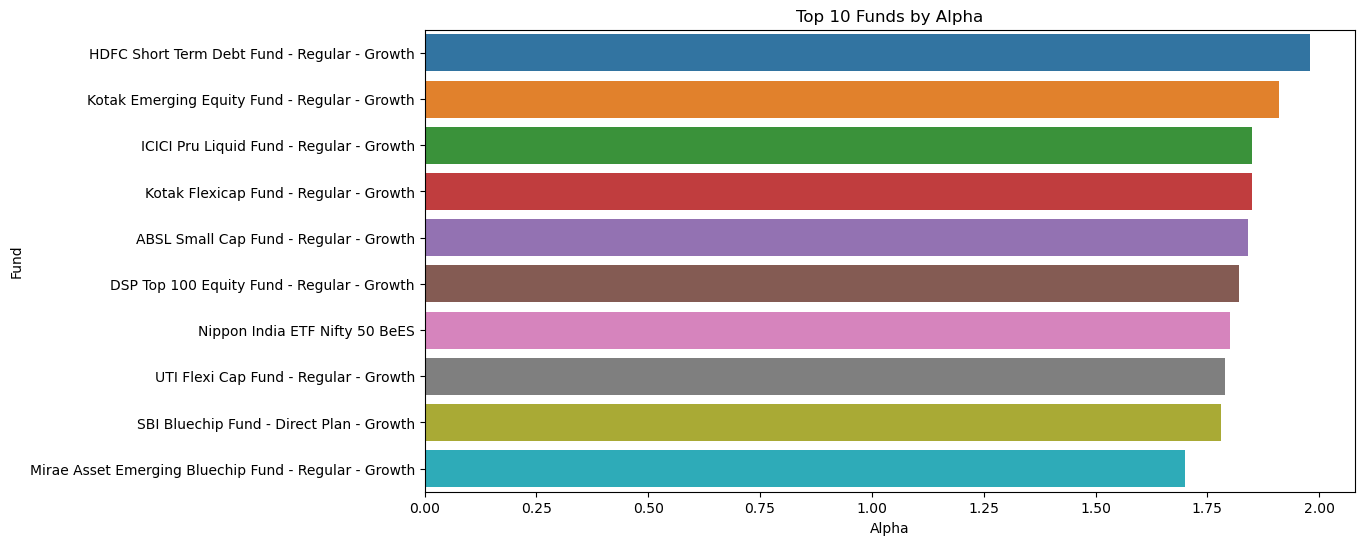

In [38]:
top10_alpha = alpha_rank.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_alpha,
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("Alpha")
plt.ylabel("Fund")

plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


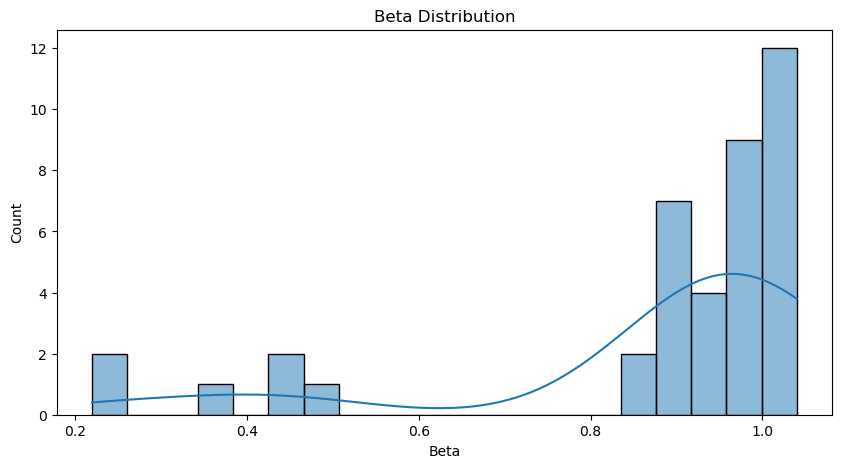

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    alpha_beta["beta"],
    bins=20,
    kde=True
)

plt.title("Beta Distribution")
plt.xlabel("Beta")

plt.show()

In [40]:
plt.savefig(
    "../reports/beta_distribution.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [41]:
plt.savefig(
    "../reports/alpha_ranking.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Alpha and Beta Analysis

Alpha measures excess return generated above the benchmark, while Beta measures market sensitivity. Funds with higher Alpha and moderate Beta generally indicate stronger risk-adjusted performance.

In [42]:
alpha_rank.head()

,amfi_code,scheme_name,fund_house,alpha,beta
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.98,0.44
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,1.91,1.00
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,1.85,0.26
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,1.85,0.95
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,1.84,0.97


In [43]:
nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()

nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [44]:
max_dd = nav.groupby("amfi_code")["drawdown"].min().reset_index()

max_dd.columns = [
    "amfi_code",
    "max_drawdown"
]

max_dd = max_dd.merge(
    performance[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code"
)

max_dd = max_dd.sort_values(
    "max_drawdown"
)

max_dd.head(10)

,amfi_code,max_drawdown,scheme_name,fund_house
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund


In [45]:
max_dd.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown file saved")

Maximum Drawdown file saved


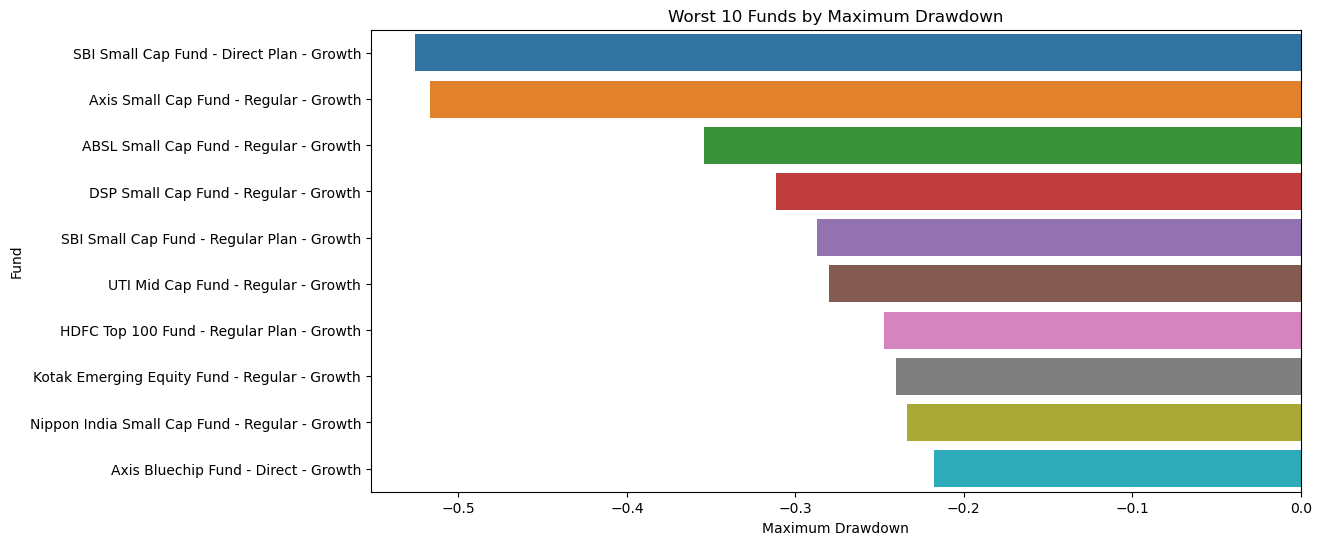

In [46]:
worst10 = max_dd.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst10,
    x="max_drawdown",
    y="scheme_name"
)

plt.title("Worst 10 Funds by Maximum Drawdown")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Fund")

plt.show()

In [47]:
plt.savefig(
    "../reports/max_drawdown.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline from a historical peak in NAV. Funds with lower drawdowns generally demonstrate better downside protection during market corrections.

In [48]:
max_dd.head()

,amfi_code,max_drawdown,scheme_name,fund_house
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund


In [49]:
scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "return_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "expense_ratio_pct"
]].copy()

scorecard = scorecard.merge(
    max_dd[["amfi_code","max_drawdown"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,12.36,0.88,0.87,1.54,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,11.30,0.81,1.78,0.66,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,0.94,1.23,1.43,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14,0.93,1.13,0.72,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,6.07,1.52,1.60,0.77,-0.043287


In [50]:
scorecard = performance[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "return_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "expense_ratio_pct"
]].copy()

scorecard = scorecard.merge(
    max_dd[["amfi_code","max_drawdown"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,12.36,0.88,0.87,1.54,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,11.30,0.81,1.78,0.66,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,0.94,1.23,1.43,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14,0.93,1.13,0.72,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,6.07,1.52,1.60,0.77,-0.043287


In [52]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(ascending=False)

In [53]:
scorecard["fund_score"] = (
    30 * (41 - scorecard["return_rank"]) / 40
    + 25 * (41 - scorecard["sharpe_rank"]) / 40
    + 20 * (41 - scorecard["alpha_rank"]) / 40
    + 15 * (41 - scorecard["expense_rank"]) / 40
    + 10 * (41 - scorecard["drawdown_rank"]) / 40
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,15.65,0.98,1.85,1.45,-0.129740,11.0,12.0,3.5,22.0,13.0,73.5000
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68,7.68,1.85,0.74,-0.000977,35.0,1.0,3.5,7.0,1.0,71.0000
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,7.37,1.84,1.98,0.56,-0.043083,36.0,4.0,1.0,2.0,4.0,70.7500
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,14.81,1.06,1.62,1.46,-0.112657,17.0,7.5,12.0,23.0,8.0,68.4375
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,18.23,0.96,1.91,1.56,-0.240035,7.0,15.0,2.0,33.0,33.0,66.2500
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,23.14,0.93,1.13,0.72,-0.525742,2.0,19.5,22.5,5.5,40.0,65.5000
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,6.18,6.18,1.52,0.60,-0.001163,37.0,2.0,14.0,3.0,2.0,64.8750
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,23.39,0.94,1.23,1.43,-0.287060,1.0,18.0,20.0,21.0,36.0,63.6250
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,22.38,0.90,1.84,1.53,-0.354469,3.0,24.5,5.0,28.5,38.0,62.2500
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,6.07,1.52,1.60,0.77,-0.043287,38.0,5.0,13.0,9.0,5.0,59.7500


In [54]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved")

Fund scorecard saved


In [55]:
plt.savefig(
    "../reports/fund_scorecard.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Fund Scorecard

The composite fund score combines return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection into a single ranking metric out of 100.

In [56]:
scorecard.head()

,amfi_code,scheme_name,fund_house,return_3yr_pct,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,15.65,0.98,1.85,1.45,-0.129740,11.0,12.0,3.5,22.0,13.0,73.5000
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68,7.68,1.85,0.74,-0.000977,35.0,1.0,3.5,7.0,1.0,71.0000
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,7.37,1.84,1.98,0.56,-0.043083,36.0,4.0,1.0,2.0,4.0,70.7500
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,14.81,1.06,1.62,1.46,-0.112657,17.0,7.5,12.0,23.0,8.0,68.4375
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,18.23,0.96,1.91,1.56,-0.240035,7.0,15.0,2.0,33.0,33.0,66.2500


In [57]:
benchmark = performance[[
    "scheme_name",
    "return_3yr_pct",
    "benchmark_3yr_pct"
]]

benchmark = benchmark.sort_values(
    "return_3yr_pct",
    ascending=False
)

top5 = benchmark.head(5)

top5

,scheme_name,return_3yr_pct,benchmark_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,22.16
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,22.01
29,ABSL Small Cap Fund - Regular - Growth,22.38,20.54
27,Axis Small Cap Fund - Regular - Growth,20.98,20.47
17,Nippon India Small Cap Fund - Regular - Growth,20.15,19.35


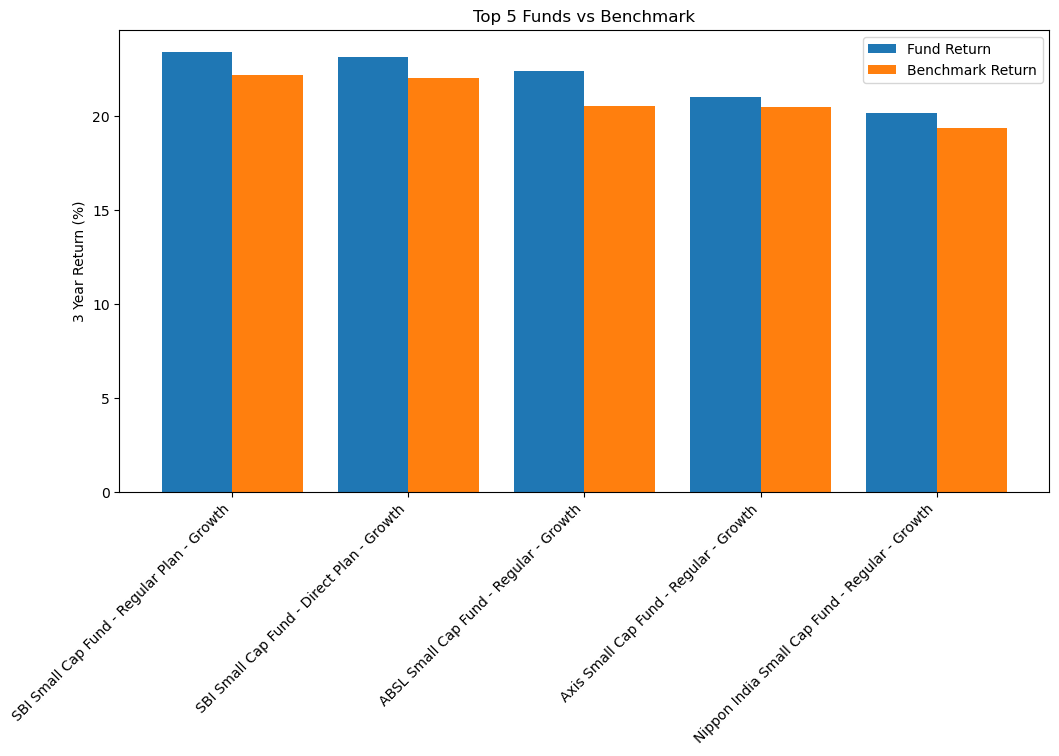

In [58]:
plt.figure(figsize=(12,6))

x = range(len(top5))

plt.bar(
    x,
    top5["return_3yr_pct"],
    width=0.4,
    label="Fund Return"
)

plt.bar(
    [i + 0.4 for i in x],
    top5["benchmark_3yr_pct"],
    width=0.4,
    label="Benchmark Return"
)

plt.xticks(
    [i + 0.2 for i in x],
    top5["scheme_name"],
    rotation=45,
    ha="right"
)

plt.ylabel("3 Year Return (%)")
plt.title("Top 5 Funds vs Benchmark")
plt.legend()

plt.show()

In [61]:
top5["tracking_error"] = abs(
    top5["return_3yr_pct"]
    -
    top5["benchmark_3yr_pct"]
)

top5[[
    "scheme_name",
    "tracking_error"
]]

C:\Users\garav\AppData\Local\Temp\ipykernel_7672\2695488684.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top5["tracking_error"] = abs(


,scheme_name,tracking_error
2,SBI Small Cap Fund - Regular Plan - Growth,1.23
3,SBI Small Cap Fund - Direct Plan - Growth,1.13
29,ABSL Small Cap Fund - Regular - Growth,1.84
27,Axis Small Cap Fund - Regular - Growth,0.51
17,Nippon India Small Cap Fund - Regular - Growth,0.80


In [62]:
top5.to_csv(
    "../reports/benchmark_comparison.csv",
    index=False
)

print("Benchmark comparison saved")

Benchmark comparison saved


In [63]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Benchmark Comparison

The benchmark comparison evaluates how the top-performing funds performed relative to their benchmark index. Tracking error measures the deviation between fund returns and benchmark returns.